In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = "./../data/lab_test_results_public.csv"

In [10]:
df = pd.read_csv(data)
df.head()

,Date,Test_Name,Result,Unit,Reference_Range,Status,Comment,Min_Reference,Max_Reference,Unit_Description,Recommended_Followup
0,2025-08-12,Ferritin,28.9,ug/L,15-150,Normal,Demir depoları alt-orta seviyede,15.00,150.0,Mikrogram/Litre,Demir açısından zengin beslenme
1,2025-08-12,Glikozile Hemoglobin (HbA1c),5.0,%,4.0-6.0,Normal,Kan şekeri uzun dönem ortalaması iyi,4.00,6.0,Yüzde,Mevcut düzeni koruma
2,2025-08-12,Total IgE,1.73,KU/L,0.1-100,Normal,Alerji riski düşük,0.10,100.0,KiloÜnite/Litre,Takip gerekmez
3,2025-08-12,İnsülin,9.42,mU/L,2.6-24.9,Normal,İnsülin normal,2.60,24.9,MiliÜnite/Litre,Mevcut düzeni koruma
4,2025-08-12,Serbest T4,1.14,ng/dL,0.87-1.70,Normal,Tiroid fonksiyonu normal,0.87,1.7,Nanogram/Desilitre,Rutin kontrol


In [12]:
column_names = df.columns.tolist()
column_names

['Date',
 'Test_Name',
 'Result',
 'Unit',
 'Reference_Range',
 'Status',
 'Comment',
 'Min_Reference',
 'Max_Reference',
 'Unit_Description',
 'Recommended_Followup']

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  27 non-null     datetime64[ns]
 1   Test_Name             27 non-null     object        
 2   Result                19 non-null     float64       
 3   Unit                  27 non-null     object        
 4   Reference_Range       27 non-null     object        
 5   Status                27 non-null     object        
 6   Comment               27 non-null     object        
 7   Min_Reference         19 non-null     float64       
 8   Max_Reference         19 non-null     float64       
 9   Unit_Description      27 non-null     object        
 10  Recommended_Followup  27 non-null     object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 2.4+ KB


In [21]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum()
})

print(missing_summary)
print("Duplicate rows:", df.duplicated().sum())

                      Missing_Count
Date                              0
Test_Name                         0
Result                            8
Unit                              0
Reference_Range                   0
Status                            0
Comment                           0
Min_Reference                     8
Max_Reference                     8
Unit_Description                  0
Recommended_Followup              0
Duplicate rows: 0


In [22]:
print(df["Result"].describe())

count     19.000000
mean      28.715789
std       60.363693
min        0.270000
25%        4.775000
50%        9.420000
75%       26.000000
max      267.000000
Name: Result, dtype: float64


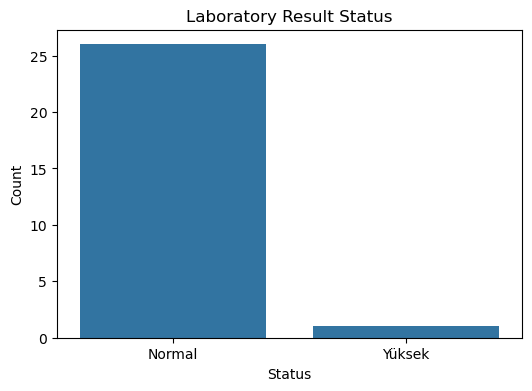

In [27]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Status")

plt.title("Laboratory Result Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [29]:
df["Within_Range"] = (
    (df["Result"] >= df["Min_Reference"]) &
    (df["Result"] <= df["Max_Reference"])
)

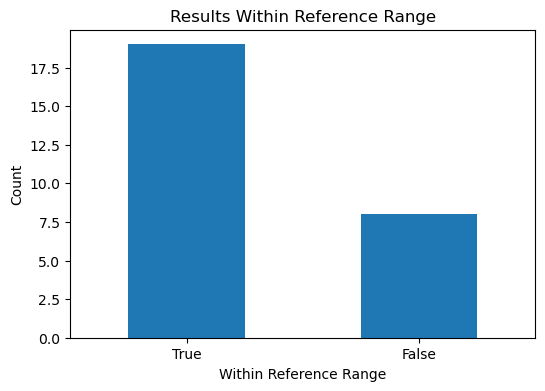

In [30]:
plt.figure(figsize=(6, 4))

df["Within_Range"].value_counts().plot(
    kind="bar"
)

plt.title("Results Within Reference Range")
plt.xlabel("Within Reference Range")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()